In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')

In [43]:
try:
  df = pd.read_csv("data_bps_datmin.csv")
  print("Dataset Loaded!")
except:
  !gdown 11zgu5vlxOhxna5ql7ralzQ5Y1BjbKi3P
  df = pd.read_csv("data_bps_datmin.csv")
  print("Dataset Loaded!")

Dataset Loaded!


# EDA

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151 entries, 0 to 150
Data columns (total 18 columns):
 #   Column                                                                  Non-Null Count  Dtype  
---  ------                                                                  --------------  -----  
 0   PROVINSI                                                                151 non-null    object 
 1   TAHUN                                                                   151 non-null    int64  
 2   APS 13-15                                                               151 non-null    float64
 3   APS 16-18                                                               151 non-null    float64
 4   APS 19-24                                                               151 non-null    float64
 5   TPT - Februari                                                          151 non-null    float64
 6   TPT - Agustus                                                           151 non-nu

In [45]:
df.head()

,PROVINSI,TAHUN,APS 13-15,APS 16-18,APS 19-24,TPT - Februari,TPT - Agustus,TPAK - Februari,TPAK - Agustus,Garis Kemiskinan - Maret (Rp),Garis Kemiskinan - September (Rp),Jumlah Penduduk Miskin - Maret (ribu),Jumlah Penduduk Miskin - September (ribu),Persentase Penduduk Miskin - Maret,Persentase Penduduk Miskin - September,Indeks Pembangunan Manusia,Rata-Rata Lama Sekolah Penduduk Umur 15 Tahun ke Atas Menurut Provinsi,Harapan Lama Sekolah (Tahun)
0,SUMATERA UTARA,2021,96.99,78.66,27.05,6.01,6.33,69.39,69.10,525756,648336,1343.86,1110.92,9.01,7.19,73.84,9.88,13.27
1,SUMATERA BARAT,2021,96.63,84.07,36.41,6.67,6.52,68.41,67.72,568703,714991,370.67,315.43,6.63,5.42,74.56,9.46,14.09
2,RIAU,2021,95.66,77.81,28.79,4.96,4.42,65.81,65.03,565937,702620,500.81,473.04,7.12,6.36,73.89,9.52,13.28
3,JAMBI,2021,96.39,72.50,24.14,4.76,5.09,67.30,67.17,506355,658100,293.86,272.70,8.09,7.26,72.62,9.03,13.04
4,SUMATERA SELATAN,2021,94.85,71.53,18.81,5.17,4.98,69.95,68.77,457455,564462,1113.76,948.84,12.84,10.51,71.83,8.78,12.54


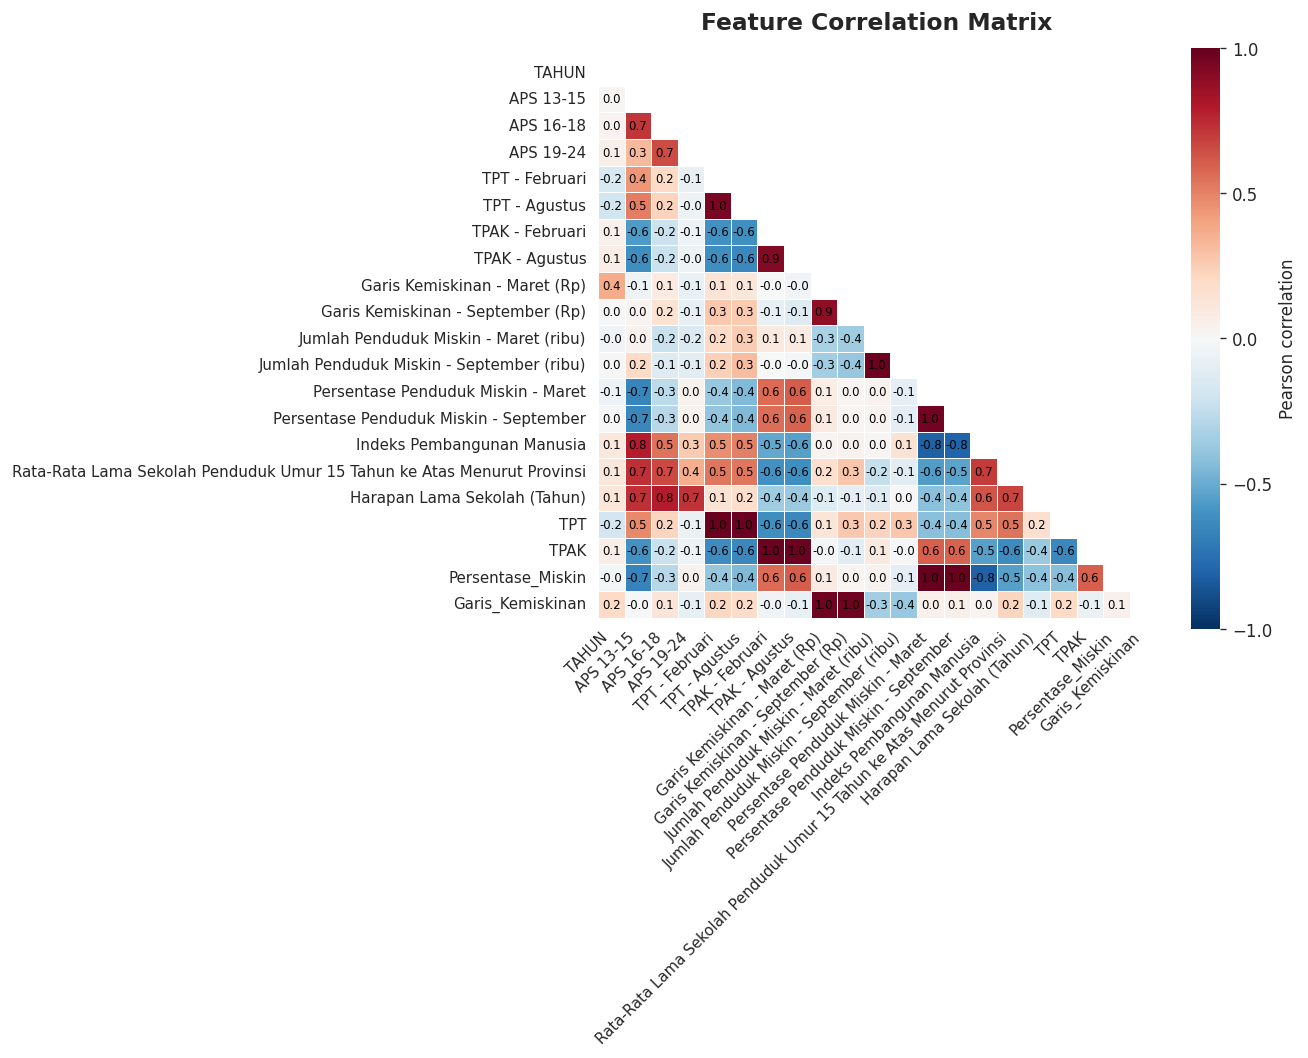

In [57]:
cols = df.select_dtypes(include=['number']).columns
corr = df[cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

sns.set_style('white')
fig, ax = plt.subplots(figsize=(11, 9), dpi=120)
sns.heatmap(corr,mask=mask,annot=True,
    fmt=".1f",
    cmap="RdBu_r",
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.6,
    linecolor="white",
    cbar_kws={
        "label": "Pearson correlation",
        "ticks": [-1, -0.5, 0, 0.5, 1],
    },
    annot_kws={"size": 7, "color": "black"},
    ax=ax,
)

ax.set_title(
    "Feature Correlation Matrix",
    fontsize=14, fontweight="bold", pad=18)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

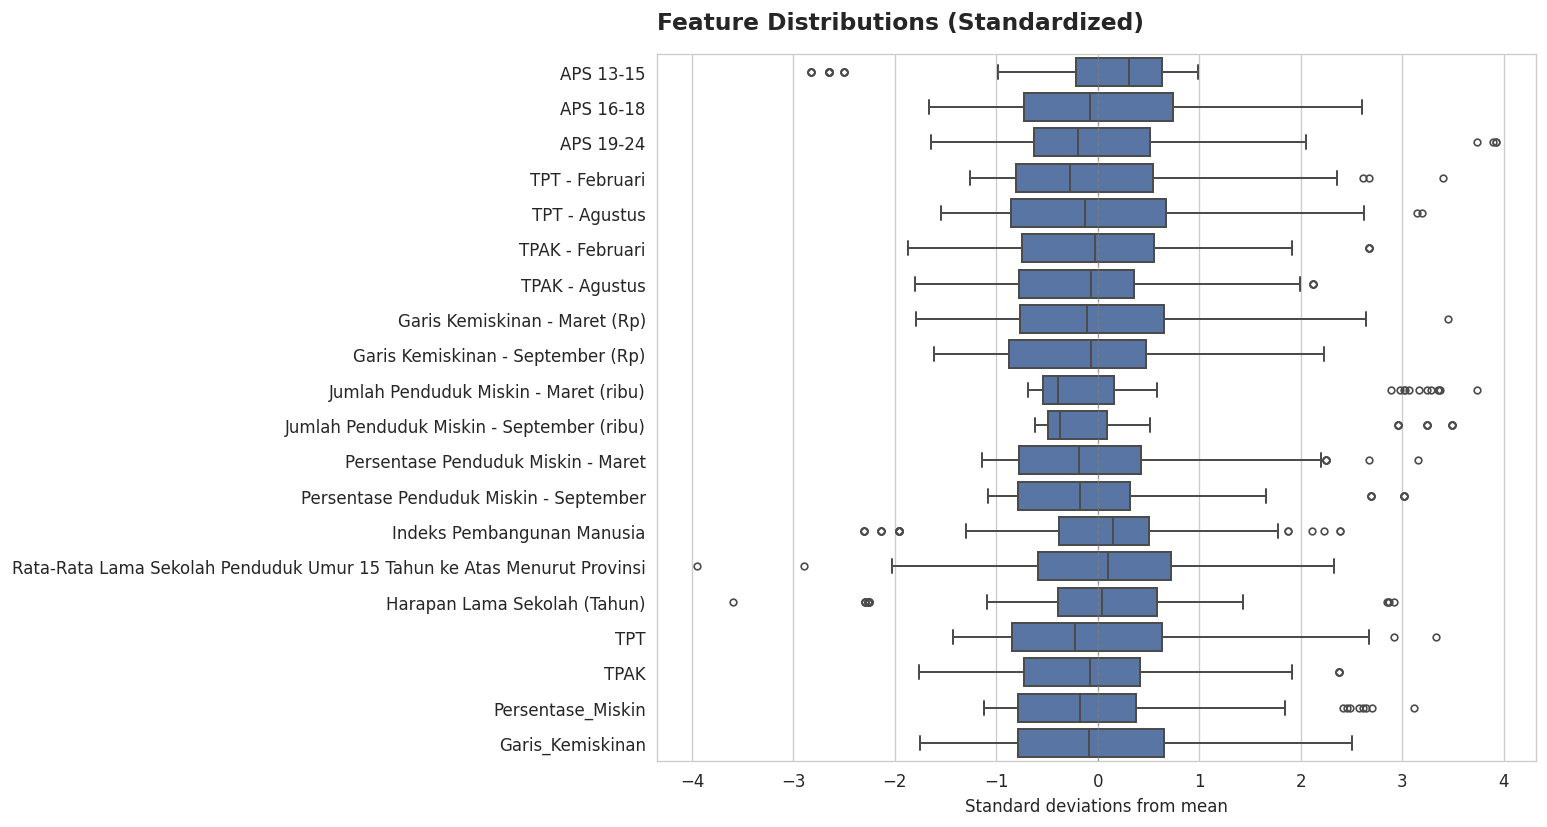

In [62]:
sns.set_style('whitegrid')
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
if 'TAHUN' in numeric_cols:
    numeric_cols.remove('TAHUN')

scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df[numeric_cols]),
    columns=numeric_cols
)
df_long = df_scaled.melt(var_name='Feature', value_name='Z-score')

fig, ax = plt.subplots(figsize=(13, 7), dpi=120)
sns.boxplot(
    data=df_long,
    x='Z-score',
    y='Feature',
    color="#4C72B0",
    fliersize=4,
    linewidth=1.2,
    ax=ax,
)

ax.axvline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax.set_title(
    'Feature Distributions (Standardized)',
    fontsize=14, fontweight='bold', pad=15, loc='left'
)
ax.set_xlabel('Standard deviations from mean')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

In [47]:
df['TPT'] = (df['TPT - Februari'] + df['TPT - Agustus']) / 2
df['TPAK'] = (df['TPAK - Februari'] + df['TPAK - Agustus']) / 2
df['Persentase_Miskin'] = (df['Persentase Penduduk Miskin - Maret']
                           + df['Persentase Penduduk Miskin - September']) / 2
df['Garis_Kemiskinan'] = (df['Garis Kemiskinan - Maret (Rp)']
                          + df['Garis Kemiskinan - September (Rp)']) / 2

selected_cols = [
    'APS 13-15', 'APS 16-18', 'APS 19-24',
    'TPT', 'TPAK',
    'Persentase_Miskin',
    'Garis_Kemiskinan',
    'Indeks Pembangunan Manusia',
    'Rata-Rata Lama Sekolah Penduduk Umur 15 Tahun ke Atas Menurut Provinsi',
    'Harapan Lama Sekolah (Tahun)'
]

In [ ]:

# ====== PLOTLY PATCH ======
import plotly.express as px
import plotly.graph_objects as go
import numpy as np

# 1. Feature Correlation Matrix
df_scaled = pd.DataFrame(X_scaled, columns=features, index=df_cluster.index)
corr = df_scaled.corr()
fig1 = px.imshow(corr, text_auto=".1f", aspect="auto", color_continuous_scale="RdBu_r", zmin=-1, zmax=1)
fig1.update_layout(title="Feature Correlation Matrix", width=900, height=800)
fig1.write_json(OUTPUT_DIR / 'plot_feature_correlation.json')

# 2. Optimum Clusters (Elbow & Silhouette)
fig2 = go.Figure()
fig2.add_trace(go.Scatter(x=K, y=inertias, mode='lines+markers', name='Inertia'))
fig2.update_layout(title="Elbow Method for Optimal k", xaxis_title="k", yaxis_title="Inertia", width=800, height=500)
fig2.write_json(OUTPUT_DIR / 'plot_optimum_clusters_elbow.json')

fig3 = go.Figure()
fig3.add_trace(go.Scatter(x=K, y=sil_scores, mode='lines+markers', name='Silhouette Score', line=dict(color='orange')))
fig3.update_layout(title="Silhouette Score for Optimal k", xaxis_title="k", yaxis_title="Silhouette Score", width=800, height=500)
fig3.write_json(OUTPUT_DIR / 'plot_optimum_clusters_silhouette.json')

# 3. K-Means 2D PCA Projection
fig4 = px.scatter(df_pca, x='PC1', y='PC2', color='cluster', hover_data=['PROVINSI'], color_discrete_sequence=px.colors.qualitative.Set1)
fig4.update_layout(title="K-Means Clustering (2D PCA Projection)", width=900, height=700)
fig4.write_json(OUTPUT_DIR / 'plot_kmeans_pca_2d.json')

# 4. K-Means 3D PCA Projection
fig5 = px.scatter_3d(df_pca, x='PC1', y='PC2', z='PC3', color='cluster', hover_data=['PROVINSI'], color_discrete_sequence=px.colors.qualitative.Set1)
fig5.update_layout(title="K-Means Clustering (3D PCA Projection)", width=1000, height=800)
fig5.write_json(OUTPUT_DIR / 'plot_kmeans_pca_3d.json')
